In [6]:
import pandas as pd
import numpy as np
import time
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
import yaml

with open("../config.yaml", "r") as file:
        config = yaml.safe_load(file)

output_dir = "../data/clean/"
config

{'input_data': {'file1': '../data/raw/2024-10-01_performance_mobile_tiles.parquet',
  'file2': '../data/raw/ADE_4-0_GPKG_WGS84G_FRA-ED2026-01-19.gpkg',
  'file3': '../data/raw/fichier_diffusion_2024.xlsx',
  'file4': '../data/raw/2024-10-01_performance_fixed_tiles.parquet'},
 'output_data': {'file1': '../data/clean/perf_admin_fr_df.csv',
  'file2': '../data/clean/file2_cleaned.csv'}}

In [4]:
df = pd.read_csv(config["output_data"]["file1"],dtype={
                                                        'code_insee_dept': str,
                                                        'code_insee_comm': str,
                                                        'zip_code': str}
                )
df.head()

,avg_down_mbps,avg_up_mbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,nbr_tests,nbr_devices,region_name,code_insee_region,code_siren_region,...,code_insee_dept,commune_name,commune_status,code_insee_comm,comm_population,zip_code,superficie_cadastrale,quadkey,geometry,LIBDENS
0,325.78,330.40,14,63.0,1496.0,1,1,NORMANDIE,28,200053403,...,50,LA HAGUE,Commune simple,50041,11484,50440,14870,313133210211310,"POLYGON ((-1.9390869140625 49.70672028103242, ...",Rural
1,318.05,462.16,9,82.0,177.0,1,1,NORMANDIE,28,200053403,...,50,LA HAGUE,Commune simple,50041,11484,50440,14870,313133210211333,"POLYGON ((-1.93359375 49.69606181911564, -1.93...",Rural
2,140.71,86.54,14,167.0,178.0,2,1,NORMANDIE,28,200053403,...,50,LA HAGUE,Commune simple,50041,11484,50440,14870,313133210300032,"POLYGON ((-1.9171142578125 49.71027258210569, ...",Rural
3,395.56,291.00,17,337.0,480.0,6,1,NORMANDIE,28,200053403,...,50,LA HAGUE,Commune simple,50041,11484,50440,14870,313133210300033,"POLYGON ((-1.91162109375 49.71027258210569, -1...",Rural
4,237.31,257.19,10,337.0,145.0,2,1,NORMANDIE,28,200053403,...,50,LA HAGUE,Commune simple,50041,11484,50440,14870,313133210300132,"POLYGON ((-1.8951416015625 49.71027258210569, ...",Rural


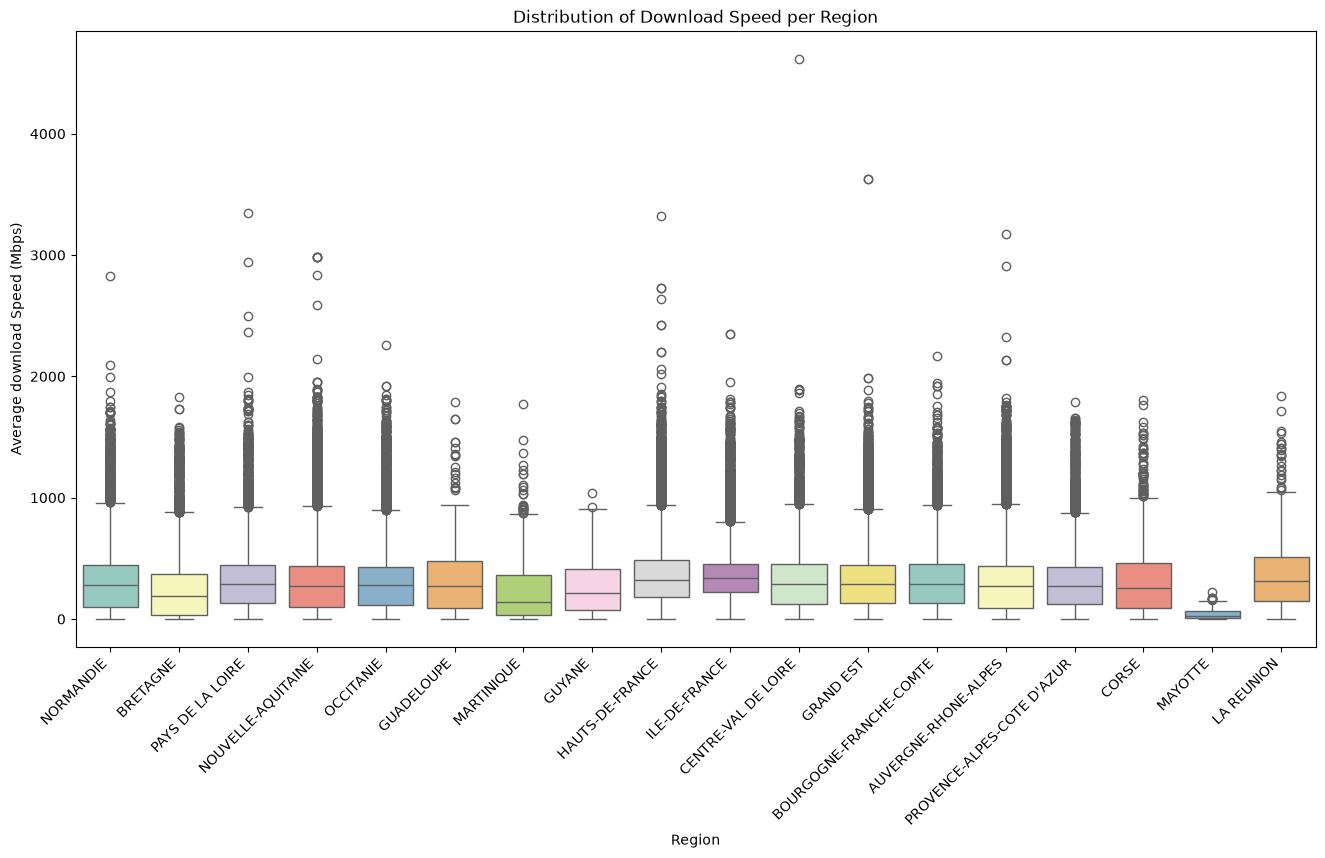

In [17]:
df_perf = df[["region_name", "avg_down_mbps","avg_up_mbps", "avg_lat_down_ms"]]
plt.figure(figsize=(16, 8))
sns.boxplot(data = df_perf, x= "region_name", y  = "avg_down_mbps", hue = "region_name", palette = "Set3", legend = False)
plt.ylabel("Average download Speed (Mbps)")
plt.xlabel("Region")
plt.title("Distribution of Download Speed per Region")
plt.xticks(rotation = 45, ha = "right")
plt.show()